# Logistic Regression: Effect of L1 and L2 Regularisation

**Student:** Yogesh Yadav  
**ID:** 24071578  
**Topic:** Logistic Regression – Regularisation (L1 vs L2)  
**Module:** Machine Learning and Neural Networks

In this notebook, I investigate how different types and strengths of regularisation affect the behaviour of Logistic Regression. The analysis focuses on:

- Synthetic 2D data to visualise how decision boundaries change.
- The Breast Cancer Wisconsin dataset to study how L1 and L2 regularisation impact model coefficients, sparsity and classification performance.

The goal is to show, in a teaching-oriented manner, how L1 regularisation can drive coefficients towards zero (sparse models), while L2 regularisation tends to shrink coefficients smoothly without forcing them to zero.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Reproducibility
RANDOM_STATE = 24071578  # student ID as seed
np.random.seed(RANDOM_STATE)

# Figure settings
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

# Create directory for figures
os.makedirs("figures_yogesh", exist_ok=True)


## Helper Function for Plotting Decision Boundaries

To visualise how Logistic Regression changes under different regularisation settings, I define a helper function that plots the decision boundary for 2D data.


In [4]:
def plot_decision_boundary_logreg(model, X, y, title, filename=None, h=0.02):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.Paired)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# Part 1 – Synthetic 2D Dataset

In this section, I generate a 2D binary classification dataset and study how different regularisation settings change the Logistic Regression decision boundary.


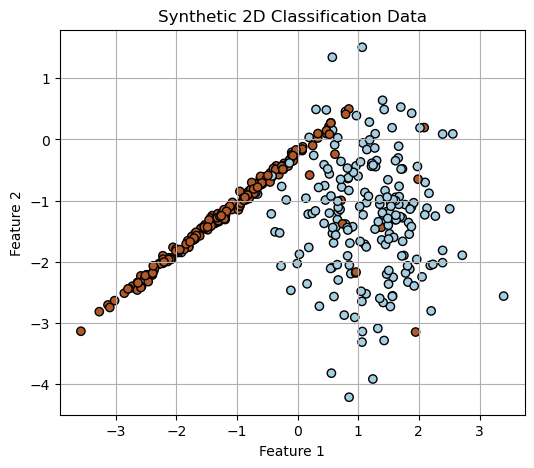

In [5]:
X_syn, y_syn = make_classification(
    n_samples=400,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.1,
    random_state=RANDOM_STATE
)

plt.scatter(X_syn[:, 0], X_syn[:, 1], c=y_syn, cmap=plt.cm.Paired, edgecolor="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic 2D Classification Data")
plt.savefig("figures_yogesh/synthetic_raw.png", dpi=300, bbox_inches="tight")
plt.show()


## L2 vs L1 Regularisation on 2D Data

Here I compare Logistic Regression with:

- L2 regularisation (ridge-style penalty)
- L1 regularisation (lasso-style penalty)

with a fixed regularisation strength.


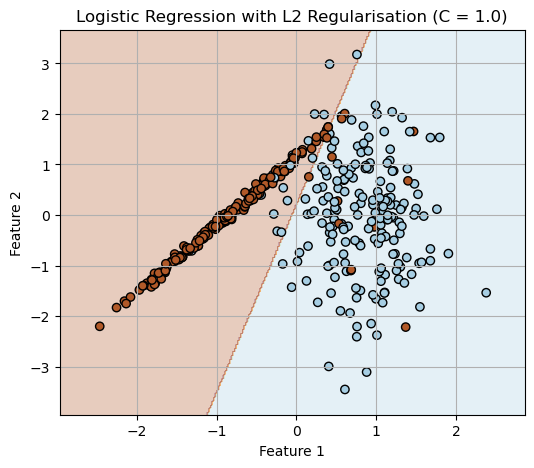

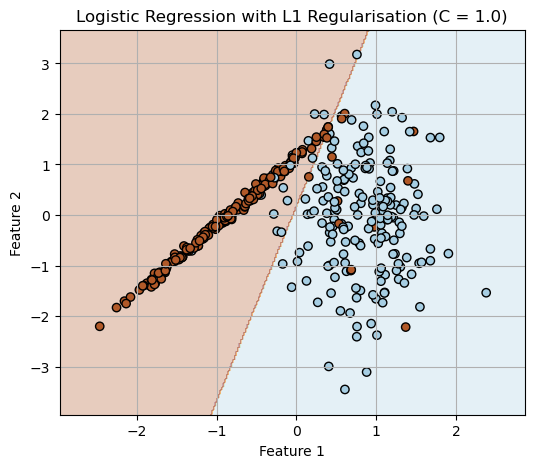

In [6]:
# Standard scaling is important for regularised logistic regression
scaler = StandardScaler()
X_syn_scaled = scaler.fit_transform(X_syn)

# L2 regularisation
logreg_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    random_state=RANDOM_STATE
)
logreg_l2.fit(X_syn_scaled, y_syn)

plot_decision_boundary_logreg(
    logreg_l2,
    X_syn_scaled,
    y_syn,
    title="Logistic Regression with L2 Regularisation (C = 1.0)",
    filename="figures_yogesh/synthetic_l2_C1.png"
)

# L1 regularisation (requires liblinear or saga for binary)
logreg_l1 = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="liblinear",
    random_state=RANDOM_STATE
)
logreg_l1.fit(X_syn_scaled, y_syn)

plot_decision_boundary_logreg(
    logreg_l1,
    X_syn_scaled,
    y_syn,
    title="Logistic Regression with L1 Regularisation (C = 1.0)",
    filename="figures_yogesh/synthetic_l1_C1.png"
)


## Effect of Regularisation Strength C on Synthetic Data

I now vary the regularisation strength C for both L1 and L2 penalties and compare train/test accuracy.


In [7]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

rows = []

X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn_scaled, y_syn, test_size=0.3, random_state=RANDOM_STATE
)

for penalty in ["l2", "l1"]:
    for C in C_values:
        solver = "lbfgs" if penalty == "l2" else "liblinear"
        clf = LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            random_state=RANDOM_STATE
        )
        clf.fit(X_train_syn, y_train_syn)
        train_acc = clf.score(X_train_syn, y_train_syn)
        test_acc = clf.score(X_test_syn, y_test_syn)
        rows.append([penalty, C, train_acc, test_acc])

df_syn = pd.DataFrame(rows, columns=["penalty", "C", "train_accuracy", "test_accuracy"])
df_syn


,penalty,C,train_accuracy,test_accuracy
0,l2,0.01,0.903571,0.916667
1,l2,0.10,0.903571,0.908333
2,l2,1.00,0.914286,0.908333
3,l2,10.00,0.914286,0.908333
4,l2,100.00,0.914286,0.908333
5,l1,0.01,0.896429,0.900000
6,l1,0.10,0.900000,0.908333
7,l1,1.00,0.917857,0.908333
8,l1,10.00,0.914286,0.908333
9,l1,100.00,0.914286,0.908333


# Part 2 – Breast Cancer Wisconsin Dataset

Next, I use the Breast Cancer Wisconsin dataset to compare L1 and L2 regularisation on a real, higher-dimensional binary classification task.


In [8]:
bc = load_breast_cancer(as_frame=True)
X_bc = bc.data
y_bc = bc.target

X_bc.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Train/Test Split and Pipelines

I split the data into training and test sets and build separate pipelines for L1 and L2-regularised Logistic Regression.


In [9]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=RANDOM_STATE
)

pipe_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=500,
        random_state=RANDOM_STATE
    ))
])

pipe_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=500,
        random_state=RANDOM_STATE
    ))
])


## Hyperparameter Tuning with GridSearchCV

I use cross-validation to find a good value of C for both L1 and L2 penalties.


In [10]:
param_grid = {"logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0]}

grid_l2 = GridSearchCV(
    pipe_l2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_l2.fit(X_train_bc, y_train_bc)

grid_l1 = GridSearchCV(
    pipe_l1,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_l1.fit(X_train_bc, y_train_bc)

grid_l2.best_params_, grid_l2.best_score_, grid_l1.best_params_, grid_l1.best_score_


({'logreg__C': 1.0},
 0.9802197802197803,
 {'logreg__C': 1.0},
 0.9758241758241759)

## Evaluation on the Test Set

I now compare the best L2 and L1 models on the held-out test set using accuracy, ROC AUC and confusion matrices.


In [11]:
best_l2 = grid_l2.best_estimator_
best_l1 = grid_l1.best_estimator_

for name, model in [("L2", best_l2), ("L1", best_l1)]:
    y_pred = model.predict(X_test_bc)
    y_proba = model.predict_proba(X_test_bc)[:, 1]
    acc = accuracy_score(y_test_bc, y_pred)
    auc = roc_auc_score(y_test_bc, y_proba)
    print(f"{name} regularisation:")
    print("  Accuracy:", acc)
    print("  ROC AUC:", auc)
    print(classification_report(y_test_bc, y_pred))
    print("-" * 40)


L2 regularisation:
  Accuracy: 1.0
  ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        72

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

----------------------------------------
L1 regularisation:
  Accuracy: 0.9824561403508771
  ROC AUC: 0.9950396825396824
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

----------------------------------------


### Confusion Matrices and ROC Curves

To visualise performance, I plot the confusion matrices and ROC curves for both L1 and L2 models.


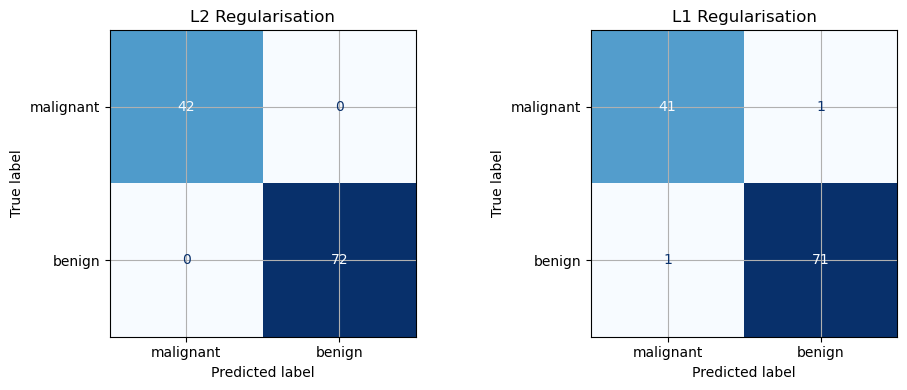

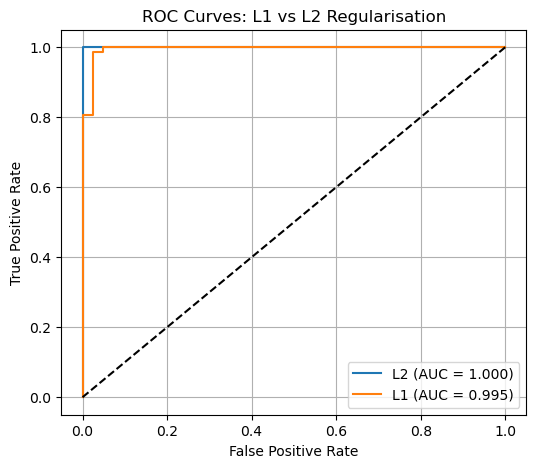

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, model) in zip(axes, [("L2", best_l2), ("L1", best_l1)]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_bc, y_test_bc,
        display_labels=bc.target_names,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )
    ax.set_title(f"{name} Regularisation")

plt.tight_layout()
plt.savefig("figures_yogesh/bc_confusion_l1_l2.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC curves
plt.figure()
for name, model in [("L2", best_l2), ("L1", best_l1)]:
    y_proba = model.predict_proba(X_test_bc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bc, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_bc, y_proba):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: L1 vs L2 Regularisation")
plt.legend()
plt.grid(True)
plt.savefig("figures_yogesh/bc_roc_l1_l2.png", dpi=300, bbox_inches="tight")
plt.show()


## Coefficient Patterns and Sparsity

To understand how L1 and L2 regularisation behave, I inspect the learned coefficients of each model.


In [13]:
coef_l2 = best_l2.named_steps["logreg"].coef_.ravel()
coef_l1 = best_l1.named_steps["logreg"].coef_.ravel()
feature_names = X_bc.columns

df_coef = pd.DataFrame({
    "feature": feature_names,
    "coef_l2": coef_l2,
    "coef_l1": coef_l1
})

df_coef_sorted = df_coef.sort_values(by="coef_l2", key=lambda s: np.abs(s), ascending=False)
df_coef_sorted.head(15)


,feature,coef_l2,coef_l1
21,worst texture,-1.285728,-1.442734
20,worst radius,-1.008976,-1.207588
23,worst area,-0.996823,-4.597811
27,worst concave points,-0.957001,-1.452154
28,worst symmetry,-0.945464,-0.546755
10,radius error,-0.944846,-0.927648
22,worst perimeter,-0.880077,0.000000
13,area error,-0.868231,0.000000
7,mean concave points,-0.834897,-0.191896
24,worst smoothness,-0.775618,-0.932584
